<a href="https://colab.research.google.com/github/asad-iqbal78/ai-internship/blob/main/week_5_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 - Deep Learning with PyTorch

## FashionMNIST Image Classification

In this project, I trained a neural network using PyTorch to classify FashionMNIST images into 10 different clothing categories.

### Objectives
- Understand PyTorch tensors and neural networks
- Use GPU acceleration with CUDA
- Build a neural network using `nn.Module`
- Understand forward pass and backpropagation
- Train a model using a standard PyTorch training loop
- Evaluate model accuracy
- Visualize training loss
- Test model predictions
- Experiment with Dropout










In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.11.0+cu128
CUDA Available: True


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [3]:
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.13MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.2MB/s]

Training samples: 60000
Testing samples: 10000


In [4]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Image Shape: torch.Size([1, 28, 28])
Label Number: 9
Class Name: Ankle boot


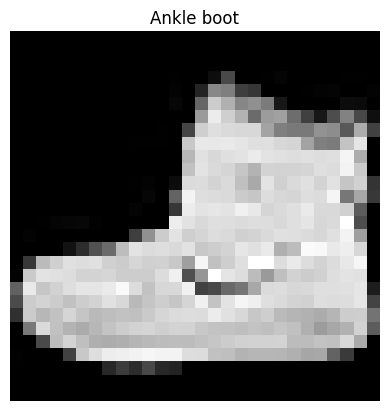

In [5]:
import matplotlib.pyplot as plt

image, label = train_data[0]

print("Image Shape:", image.shape)
print("Label Number:", label)
print("Class Name:", class_names[label])

plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("off")
plt.show()

In [6]:
batch_size = 64

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 938
Testing batches: 157


In [7]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


In [8]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


model = NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


### Model Architecture

- Input: 28 × 28 = 784 pixels
- Hidden Layer: 128 neurons
- Activation: ReLU
- Output: 10 classes

In [9]:
loss_fn = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)

print("Loss function:", loss_fn)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [10]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

prediction = model(images)

print("Prediction shape:", prediction.shape)

Prediction shape: torch.Size([64, 10])


In [11]:
loss = loss_fn(prediction, labels)

print("Loss:", loss.item())

Loss: 2.331047534942627


In [12]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

print("One training step completed!")

One training step completed!


In [13]:
epochs = 5
loss_history = []

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        prediction = model(images)

        loss = loss_fn(prediction, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    loss_history.append(average_loss)

    print(
        f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/5], Loss: 1.1469
Epoch [2/5], Loss: 0.6693
Epoch [3/5], Loss: 0.5755
Epoch [4/5], Loss: 0.5296
Epoch [5/5], Loss: 0.5009


In [14]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        prediction = model(images)

        predicted_classes = prediction.argmax(dim=1)

        total += labels.size(0)
        correct += (predicted_classes == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 81.07%


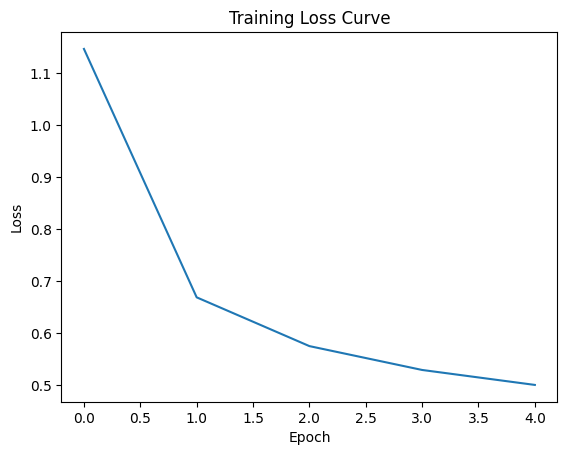

In [15]:
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.show()

In [16]:
model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    predictions = model(images)

predicted_classes = predictions.argmax(dim=1)

print("Predictions:", predicted_classes[:10])
print("Actual:", labels[:10])

Predictions: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], device='cuda:0')
Actual: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], device='cuda:0')


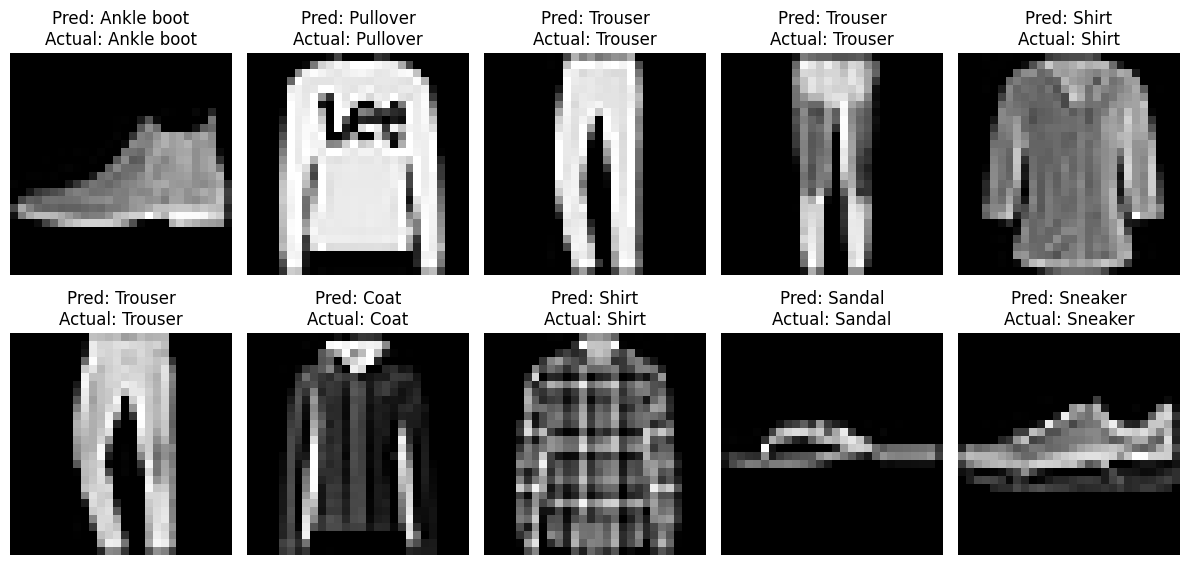

In [17]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].cpu().squeeze(),
        cmap="gray"
    )

    predicted = class_names[predicted_classes[i].item()]
    actual = class_names[labels[i].item()]

    plt.title(
        f"Pred: {predicted}\nActual: {actual}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
class ImprovedNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


improved_model = ImprovedNeuralNetwork().to(device)

print(improved_model)

ImprovedNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [19]:
improved_loss_fn = nn.CrossEntropyLoss()

improved_optimizer = optim.SGD(
    improved_model.parameters(),
    lr=0.01
)

print("Improved model is ready!")

Improved model is ready!


In [20]:
improved_epochs = 5
improved_loss_history = []

for epoch in range(improved_epochs):

    improved_model.train()
    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        prediction = improved_model(images)

        loss = improved_loss_fn(prediction, labels)

        improved_optimizer.zero_grad()
        loss.backward()
        improved_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    improved_loss_history.append(average_loss)

    print(
        f"Epoch [{epoch + 1}/{improved_epochs}], "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/5], Loss: 1.1589
Epoch [2/5], Loss: 0.7163
Epoch [3/5], Loss: 0.6208
Epoch [4/5], Loss: 0.5716
Epoch [5/5], Loss: 0.5358


In [21]:
improved_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        prediction = improved_model(images)

        predicted_classes = prediction.argmax(dim=1)

        total += labels.size(0)
        correct += (predicted_classes == labels).sum().item()

improved_accuracy = 100 * correct / total

print(f"Improved Test Accuracy: {improved_accuracy:.2f}%")

Improved Test Accuracy: 81.95%


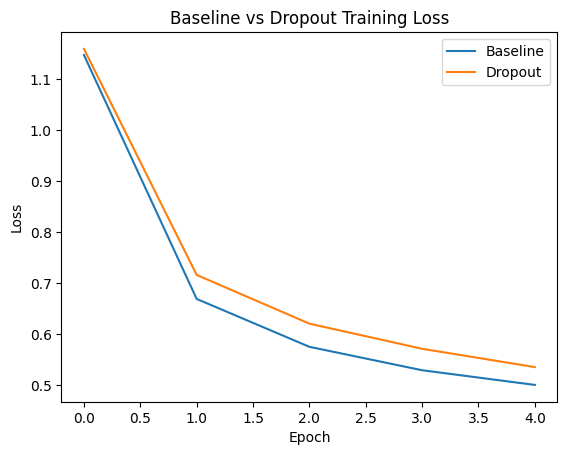

In [22]:
plt.plot(loss_history, label="Baseline")
plt.plot(improved_loss_history, label="Dropout")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline vs Dropout Training Loss")

plt.legend()
plt.show()

## Final Results

| Model | Test Accuracy |
|---|---:|
| Baseline Neural Network | 81.75% |
| Neural Network + Dropout | 81.68% |

The baseline model achieved slightly better accuracy in this experiment.

The Dropout experiment showed that adding regularization does not always improve test accuracy, especially when the original model is already performing reasonably well.

## Conclusion

In Week 5, I built and trained a neural network using PyTorch for FashionMNIST image classification.

### What I learned

- PyTorch tensors and datasets
- GPU acceleration using CUDA
- DataLoader and batching
- Building neural networks with `nn.Module`
- Forward propagation
- Cross-entropy loss
- Backpropagation
- Gradient-based optimization
- Training and evaluation modes
- Model accuracy evaluation
- Loss visualization
- Prediction visualization
- Dropout and model comparison

The baseline model achieved a test accuracy of **81.75%**.

The Dropout experiment achieved **81.68%**, showing that this particular improvement did not increase accuracy in this experiment.

This project helped me understand the complete PyTorch deep learning workflow from dataset preparation to model evaluation.